In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2-4*x+5

In [3]:
f(3.0)


20.0

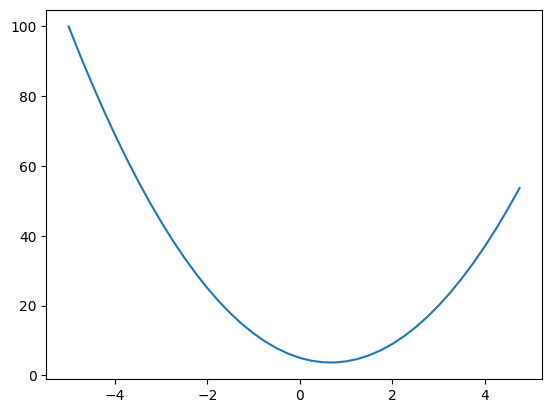

In [4]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [5]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        # internal variables used for autograd graph construction
        self._prev = set(_children)
        self._backward= lambda:None
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
        self.grad = 0

    def __repr__(self):
        return f"Value(data={self.data})"

        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad+= out.grad
            other.grad+= out.grad
        out._backward=_backward
        return out

    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad += out.grad* other.data
            other.grad += out.grad * self.data
        out._backward=_backward
        return out

    def tanh(self):
        out= Value((np.exp(2*self.data)-1)/(np.exp(2*self.data)+1),(self,),'tanh')
        def _backward():
            self.grad= out.grad * (1-out.data**2)
        out._backward=_backward
        return out 

    def backward(self):
        topo=[]
        visited=set()
        topo.append(self)
        def visit(v): 
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    topo.append(child)
                    visit(child)
        visit(self)
        print(topo)
        self.grad=1.0
        for node in topo:
            node._backward()

In [20]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)

    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin,nout):
        self.n=[Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        out= [neuron(x) for neuron in self.n]
        return out[0] if len(out)==1 else out

    def parameters(self):
        return [p for neuron in self.n for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        sz= [nin]+nouts
        self.L= [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for l in self.L:
            x=l(x)
        return x

    def parameters(self):
        return [p for layer in self.L for p in layer.parameters()]

        

In [21]:
import os
import sys
import shutil
from pathlib import Path

# Jupyter may start without the Conda environment's executable directories on PATH.
if os.name == "nt" and shutil.which("dot") is None:
    graphviz_bin = Path(sys.prefix) / "Library" / "bin"
    if (graphviz_bin / "dot.exe").is_file():
        os.environ["PATH"] = str(graphviz_bin) + os.pathsep + os.environ.get("PATH", "")

from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{  data %.4f | grad %.4f}" % (n.data,n.grad),
            shape='record'
        )

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(
                name=uid + n._op,
                label=n._op
            )

            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [24]:
x=[1.0,2.0,-1.0]
m=MLP(3,[4,3,1])
out=m(x)
len(m.parameters())

35

[Value(data=-0.39983049593939957), Value(data=-0.42344715592898535), Value(data=-0.027106476668299604), Value(data=0.5181124852563976), Value(data=0.5737561706278763), Value(data=0.1399914748004818), Value(data=-0.2595705444921792), Value(data=0.467078975363281), Value(data=0.506327684761662), Value(data=-0.07634394427179281), Value(data=-0.9662013120691726), Value(data=-0.9662013120691726), Value(data=1.0), Value(data=-0.9662013120691726), Value(data=0), Value(data=0.8898573677973798), Value(data=0.4449286838986899), Value(data=2.0), Value(data=0.5826716290334548), Value(data=-0.5826716290334548), Value(data=-1.0), Value(data=-0.5557315961188201), Value(data=0.399562019292661), Value(data=0.7414128501943854), Value(data=0.7414128501943854), Value(data=0.8203393703933779), Value(data=1.1578542748540597), Value(data=0.06658852057502407), Value(data=-1.0), Value(data=-0.06658852057502407), Value(data=1.0912657542790356), Value(data=0.8396177940774474), Value(data=2.0), Value(data=0.41980

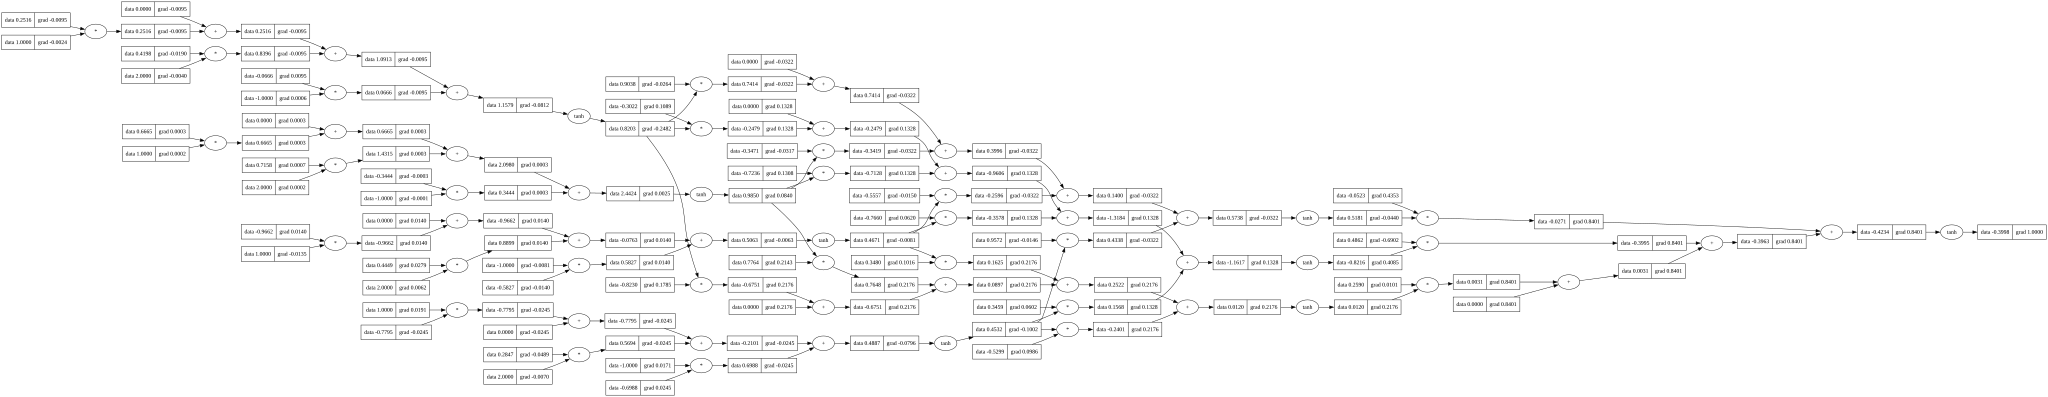

In [19]:
x=[1.0,2.0,-1.0]
m=MLP(3,[4,3,1])
out=m(x)
out.backward()
draw_dot(out)
